# Combined examples

This notebook collects all of the example notebooks in one place. The first code cell imports every library that any example needs, and each section after that reproduces one of the original examples, in order.

In [1]:
import os, sys

# Make the project packages importable and resolve data paths from the repo root,
# whether this notebook is launched from the repo root or from examples/.
_cwd = os.getcwd()
for _cand in (_cwd, os.path.dirname(_cwd)):
    if os.path.isdir(os.path.join(_cand, 'reservoirs')):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        os.chdir(_cand)
        break

from pathlib import Path
import numpy as np, pandas as pd, random
from reservoirs.random import Reservoir, Reservoir2, Reservoir3, ErdosRenyiReservoir
import matplotlib.pyplot as plt
import warnings
from reservoirs.connectome import ConnectomeReservoir
import warnings, numpy as np
import slither
from slither.config import LEAK_RANGE, INPUT_SCALE, T_WASHOUT, ALPHA, WINDOW_LEN, WINDOW_STRIDE
import pandas as pd
from slither.config import ANGLE_MIN, ANGLE_MAX, ANGLE_RESOLUTION, NUM_ANGLE_BINS
import numpy as np
import numpy as np, matplotlib.pyplot as plt
import random, pandas as pd
from reservoirs.random import Reservoir
from reservoirs.learning import OnlineReadout
from reservoirs.learning import RLSReadout
from reservoirs.learning import OnlineReadout, ContinualBenchmark
from reservoirs.learning import ConceptorClassifier
from reservoirs.learning import ConceptorReadout, ContinualBenchmark
import random, pandas as pd, warnings
from reservoirs.nulls import rewire_degree_preserving
from reservoirs import tasks as rc_tasks
from reservoirs.tuning import (random_search, default_reservoir_space,
                               train_val_test_split, build_reservoir)
from reservoirs.baselines import (majority_class_baseline, linear_readout_baseline,
                                  logistic_readout_baseline)
from reservoirs import tasks as rc_tasks   # NB: alias, so we never shadow the module name

## esn tutorial iris

# 01: Echo State Network on Iris (random reservoirs)

The idea here is to classify Iris flowers by turning each flower's 4 features into sine-encoded time series, feeding those into a frozen random reservoir (`reservoirs.random`), and training only a ridge readout on top. You choose the connectivity with a single variable. This pulls together the old `handson_*` notebooks (fully-connected, ring, and gaussian) and adds a genuine Erdős-Rényi reservoir as well.

In [2]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
print('repo root set:', REPO.name)   # name only, no absolute path

repo root set: ESN-unofficial-1-utilizzando-matrici-random-con-iris


In [3]:
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0))
data_raw = df.to_numpy().astype(float)
rng = random.Random(7)
sample = lambda a, b: rng.sample(range(a, b), 40)
train_idxs = sample(0,50)+sample(50,100)+sample(100,150)
test_idxs = [i for i in range(150) if i not in train_idxs]
data = data_raw.copy()
data[:, :4] = data[:, :4] / data[train_idxs, :4].max(axis=0)
timesteps = np.arange(0, 50, 0.5)   # 100 steps (raise resolution -> higher accuracy, slower)
u = np.array([np.vstack([np.sin(timesteps*2*np.pi*pt[i]) for i in range(4)]).T for pt in data[:, :4]])
y = np.array([data[:, 4:]] * len(timesteps)).swapaxes(0, 1).astype(float)
u_train, u_test, y_train, y_test = u[train_idxs], u[test_idxs], y[train_idxs], y[test_idxs]
print('iris encoded:', u.shape, '-> classes', y.shape[-1])

iris encoded: (150, 100, 4) -> classes 3


In [4]:
WASHOUT, ALPHA_IRIS = 10, 1e-4
def collect(res, batch):
    return np.stack([res.forward(seq, collect_states=True) for seq in batch], axis=0)
def ridge(Xs, Ys, washout=WASHOUT, alpha=ALPHA_IRIS):
    X = Xs[:, washout:, :].reshape(-1, Xs.shape[-1]); Y = Ys[:, washout:, :].reshape(-1, Ys.shape[-1])
    return np.linalg.solve(X.T @ X + alpha*np.eye(X.shape[1]), X.T @ Y)
def series_acc(pred, Yt):
    return float(np.mean(pred.mean(1).argmax(1) == Yt.mean(1).argmax(1)))
def evaluate(res):
    Xtr, Xte = collect(res, u_train), collect(res, u_test)
    w = ridge(Xtr, y_train)
    return series_acc(Xtr @ w, y_train), series_acc(Xte @ w, y_test)

### Compare connectivities
The classes map to topologies as follows: `Reservoir` is fully-connected, `Reservoir2` is a ring, `Reservoir3` is gaussian, and `ErdosRenyiReservoir` is the genuinely sparse one.

In [5]:
rows = []
for name, make in [
    ('fully_connected', lambda: (np.random.seed(7), Reservoir(4, 100, rhow=1.25))[1]),
    ('ring',            lambda: (np.random.seed(7), Reservoir2(4, 100, rhow=1.25))[1]),
    ('gaussian',        lambda: (np.random.seed(7), Reservoir3(4, 100, rhow=1.25))[1]),
    ('erdos_renyi',     lambda: ErdosRenyiReservoir(4, 100, rhow=1.25, density=0.1, seed=7)),
]:
    tr, te = evaluate(make())
    rows.append({'connectivity': name, 'train_acc': round(tr,3), 'test_acc': round(te,3)})
res = pd.DataFrame(rows); print(res.to_string(index=False)); res

   connectivity  train_acc  test_acc
fully_connected      0.942     0.900
           ring      0.333     0.333
       gaussian      0.933     0.833
    erdos_renyi      0.942     0.867


,connectivity,train_acc,test_acc
0,fully_connected,0.942,0.900
1,ring,0.333,0.333
2,gaussian,0.933,0.833
3,erdos_renyi,0.942,0.867


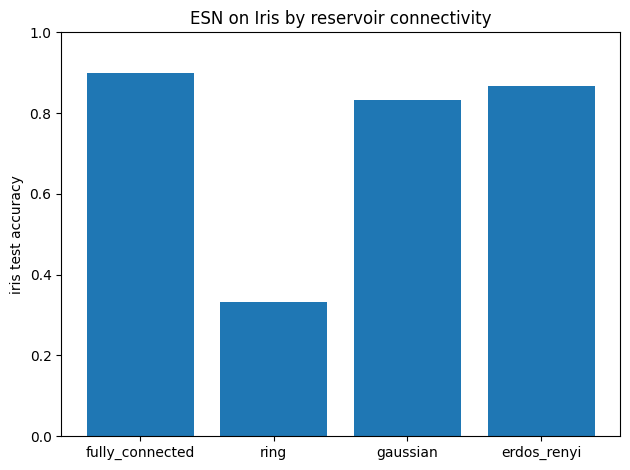

In [6]:
plt.bar(res['connectivity'], res['test_acc']); plt.ylabel('iris test accuracy')
plt.title('ESN on Iris by reservoir connectivity'); plt.ylim(0,1); plt.tight_layout(); plt.show()

What stands out: the bidirectional ring reservoir collapses to chance (about 0.33), because its purely oscillatory spectrum is a poor match for this task. The fully-connected, gaussian, and Erdős-Rényi reservoirs all learn. Accuracy climbs as you add timesteps (`np.arange(0,50,0.1)` gives 500 steps) and neurons.

## connectome iris

# 02: Connectome reservoir on Iris

This is the same Iris benchmark as notebook 01, except the recurrent matrix is a brain connectome (`reservoirs.connectome.ConnectomeReservoir`) rather than a random matrix. That lets you compare biological and random connectivity on identical data. It runs on the committed mock 60-node connectome; to get paper-grade results, point `GRAPH_DIR` at a real connectome folder.

> Edge weights. The mock connectome has a `weight` attribute, so the default works here. For the real HCP GraphMLs in `data/connectomes/scale83` you have to pass `edge_attr='number_of_fibers'`, because those graphs have no `weight` attribute. Without it the default falls back to a binary (topology-only) reservoir and the engine warns. See `docs/METHODOLOGY.md` and `docs/AUDIT.md` F1.

> Limitation. Structural connectomes from non-invasive imaging are undirected, so `symmetric=True` is correct here, and the reservoir has a real-eigenvalue-only spectrum (no oscillatory modes).

In [7]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
print('repo root set:', REPO.name)   # name only, no absolute path

repo root set: ESN-unofficial-1-utilizzando-matrici-random-con-iris


In [8]:
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0))
data_raw = df.to_numpy().astype(float)
rng = random.Random(7)
sample = lambda a, b: rng.sample(range(a, b), 40)
train_idxs = sample(0,50)+sample(50,100)+sample(100,150)
test_idxs = [i for i in range(150) if i not in train_idxs]
data = data_raw.copy()
data[:, :4] = data[:, :4] / data[train_idxs, :4].max(axis=0)
timesteps = np.arange(0, 50, 0.5)   # 100 steps (raise resolution -> higher accuracy, slower)
u = np.array([np.vstack([np.sin(timesteps*2*np.pi*pt[i]) for i in range(4)]).T for pt in data[:, :4]])
y = np.array([data[:, 4:]] * len(timesteps)).swapaxes(0, 1).astype(float)
u_train, u_test, y_train, y_test = u[train_idxs], u[test_idxs], y[train_idxs], y[test_idxs]
print('iris encoded:', u.shape, '-> classes', y.shape[-1])

iris encoded: (150, 100, 4) -> classes 3


In [9]:
WASHOUT, ALPHA_IRIS = 10, 1e-4
def collect(res, batch):
    return np.stack([res.forward(seq, collect_states=True) for seq in batch], axis=0)
def ridge(Xs, Ys, washout=WASHOUT, alpha=ALPHA_IRIS):
    X = Xs[:, washout:, :].reshape(-1, Xs.shape[-1]); Y = Ys[:, washout:, :].reshape(-1, Ys.shape[-1])
    return np.linalg.solve(X.T @ X + alpha*np.eye(X.shape[1]), X.T @ Y)
def series_acc(pred, Yt):
    return float(np.mean(pred.mean(1).argmax(1) == Yt.mean(1).argmax(1)))
def evaluate(res):
    Xtr, Xte = collect(res, u_train), collect(res, u_test)
    w = ridge(Xtr, y_train)
    return series_acc(Xtr @ w, y_train), series_acc(Xte @ w, y_test)

In [10]:
GRAPH_DIR = 'generated_artifacts/graphs'   # <- swap for a real connectome folder
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    res = ConnectomeReservoir(4, graph_dir=GRAPH_DIR, spectral_radius=0.9, seed=7)
tr, te = evaluate(res)
print(f'connectome reservoir  N={res.n_neurons}  train_acc={tr:.3f}  test_acc={te:.3f}')

connectome reservoir  N=60  train_acc=0.850  test_acc=0.733


Set against notebook 01's random reservoirs of the same size, this tells you whether the empirical connectome topology actually helps on Iris. A proper claim also needs the null-model baselines (a degree-preserving rewired version plus a size-matched random ESN), which were added in Phase 4.

## slither pipeline

# 03: Slither.io gameplay prediction (connectome reservoir)

This is an end-to-end pipeline. Per-frame slither.io state tensors become features, those drive a frozen connectome reservoir, the reservoir states feed a ridge readout, and the readout predicts the player's next steering angle (binned) and boost. It uses the `slither` package together with `reservoirs.connectome`, running on the committed mock demo sessions and mock connectome, so no private data is needed.

In [11]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
print('repo root set:', REPO.name)   # name only, no absolute path

repo root set: ESN-unofficial-1-utilizzando-matrici-random-con-iris


In [12]:
DATA, GRAPH = Path('data'), Path('generated_artifacts/graphs')
slither.ensure_mock_graph(GRAPH); slither.ensure_mock_data(DATA)
X_list, y_list, names = slither.load_all_sessions(DATA)
u, y, sid = slither.make_windows(X_list, y_list, WINDOW_LEN, WINDOW_STRIDE)
print('sessions:', names, '| windows:', u.shape, '-> outputs', y.shape[-1])

sessions: ['session_1001', 'session_1002', 'session_1003'] | windows: (45, 25, 6149) -> outputs 18


### Train the readout and evaluate
We report two splits: the original window-shuffled one and the leakage-free session-grouped one. Overlapping windows share frames, so shuffling them leaks information across the split; grouping by session avoids that.

In [13]:
def run(group):
    u_tr,y_tr,u_te,y_te,_,_ = slither.train_test_split_windows(u,y,sid,seed=7,group_by_session=group)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        res = ConnectomeReservoir(n_inputs=u_tr.shape[2], graph_dir=str(GRAPH), edge_attr='weight',
            combine='mean', rhow=1.05, leak_range=LEAK_RANGE, symmetric=True, seed=7, input_scale=INPUT_SCALE)
    st = res.collect_states_batch   # Phase-5 vectorized fast path
    Xtr, Xte = st(u_tr), st(u_te)
    w = slither.compute_wout(Xtr, y_tr, washout=T_WASHOUT, alpha=ALPHA)
    out = []
    for split, P, Y in [('train', Xtr@w, y_tr), ('test', Xte@w, y_te)]:
        out.append({'split':split,'angle_acc':round(slither.angle_accuracy(P,Y),3),
                    'boost_acc':round(slither.boost_accuracy(P,Y),3),'mse':round(float(np.mean((P-Y)**2)),4)})
    return res, pd.DataFrame(out), (Xte@w, y_te)
res, m_leaky, _ = run(False); res, m_group, (pred_te, y_te) = run(True)
print('window-shuffled split (leaky):'); print(m_leaky.to_string(index=False))
print('\nsession-grouped split (leakage-free):'); print(m_group.to_string(index=False))
print('reservoir neurons:', res.n_neurons)

window-shuffled split (leaky):
split  angle_acc  boost_acc    mse
train      0.794      0.854 0.0195
 test      0.698      0.804 0.0273

session-grouped split (leakage-free):
split  angle_acc  boost_acc    mse
train      0.747      0.904 0.0197
 test      0.693      0.739 0.0643
reservoir neurons: 60


In [14]:
# Sanity check: how much of the mock label is solvable WITHOUT the reservoir, from the leaked
# previous-heading features alone? On this mock it rivals/beats the reservoir above, which is why
# these numbers measure leakage, not modelling skill (see slither/mock.py + docs/AUDIT.md F4).
for group in (False, True):
    u_tr, y_tr, u_te, y_te, _, _ = slither.train_test_split_windows(u, y, sid, seed=7, group_by_session=group)
    base = slither.leaked_feature_baseline(u_tr, y_tr, u_te, y_te)
    tag = 'session-grouped' if group else 'window-shuffled'
    print(f'{tag:16s}: NO-reservoir baseline angle_acc = {base:.3f}  (vs reservoir above)')

window-shuffled : NO-reservoir baseline angle_acc = 0.555  (vs reservoir above)


session-grouped : NO-reservoir baseline angle_acc = 0.740  (vs reservoir above)


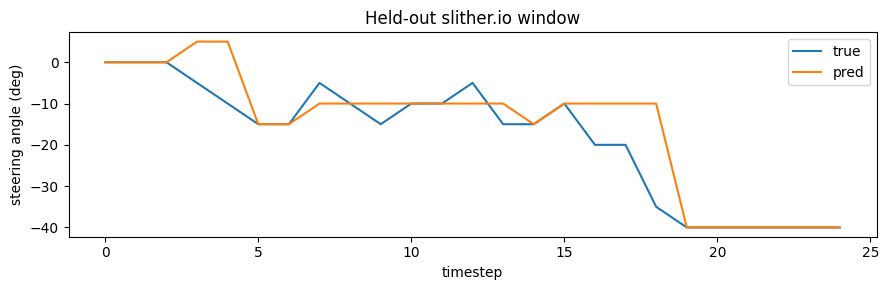

In [15]:
angles = np.arange(ANGLE_MIN, ANGLE_MAX+ANGLE_RESOLUTION, ANGLE_RESOLUTION)
tb = y_te[0,:,:NUM_ANGLE_BINS].argmax(1); pb = pred_te[0,:,:NUM_ANGLE_BINS].argmax(1)
plt.figure(figsize=(9,3)); plt.plot(angles[tb], label='true'); plt.plot(angles[pb], label='pred')
plt.ylabel('steering angle (deg)'); plt.xlabel('timestep'); plt.legend()
plt.title('Held-out slither.io window'); plt.tight_layout(); plt.show()

A few caveats. These numbers come from synthetic mock data and a 60-node mock connectome, so they validate the pipeline rather than make a scientific claim. The mock is also heavily leaked. The angle label is essentially the previous-step heading, so a no-reservoir ridge on the `prev_sin` and `prev_cos` features alone (the cell above) rivals or beats the reservoir. The boost label is `velocity>110`, which is roughly 100% recoverable from a single input feature. Treat the reservoir numbers as plumbing checks only (see `slither/mock.py` and `docs/AUDIT.md` F4). The leakage-free session-grouped split shows the honest, higher MSE. To get real results, drop scraper sessions under `data/<user>/session_*` and a real connectome under `generated_artifacts/graphs/`, and pass `edge_attr='number_of_fibers'` for HCP GraphMLs.

## continuous time dynamics

# 04: Continuous-time reservoir dynamics

A standalone study, taken from the original `project1.ipynb`. It integrates a continuous-time rate model `dr/dt = -r + sigmoid(A r)` with explicit Euler steps across three connectivity topologies (fully-connected, Erdős-Rényi, and gaussian) and plots the population dynamics. This is the only continuous-time formulation in the repo, and it is kept as-is.

In [16]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5
def euler_integrate(A, r_init, dt=0.1, T=100):
    N = len(r_init)
    r = np.zeros((T, N))
    r[0] = r_init
    
    for t in range(1, T):
        dr_dt = -r[t-1] + sigmoid(A @ r[t-1])
        r[t] = r[t-1] + dt * dr_dt
    
    return r

def fully_connected(N, J):
    return np.full((N, N), J / N)

def erdos_renyi(N, J, p):
    k = max(1, int(p * N))
    A = (np.random.rand(N, N) < p).astype(float) * (J / k)
    np.fill_diagonal(A, 0)
    return A

def gaussian_random(N, J):
    A = np.random.normal(0, J**2 / N, (N, N))
    np.fill_diagonal(A, 0)
    return A

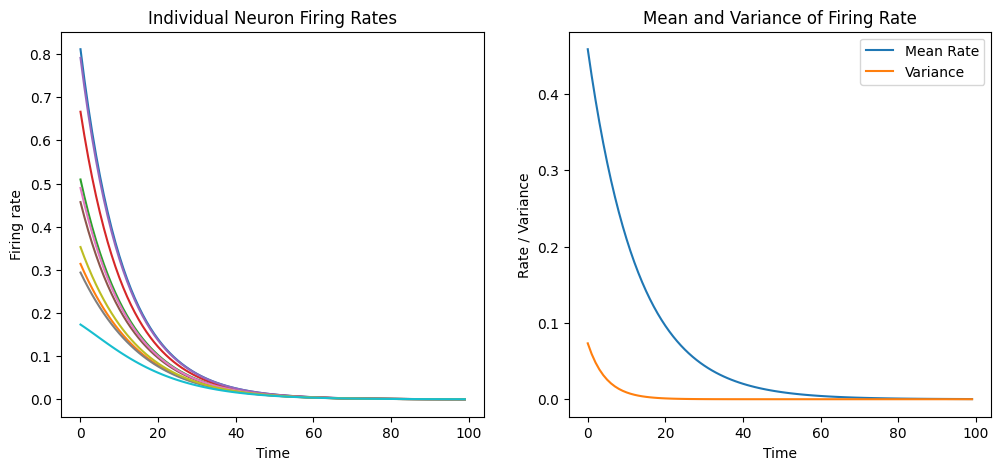

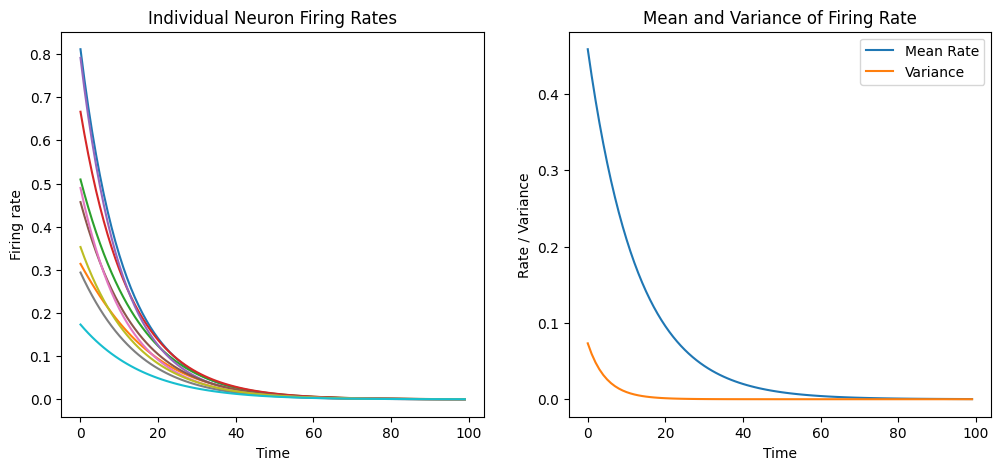

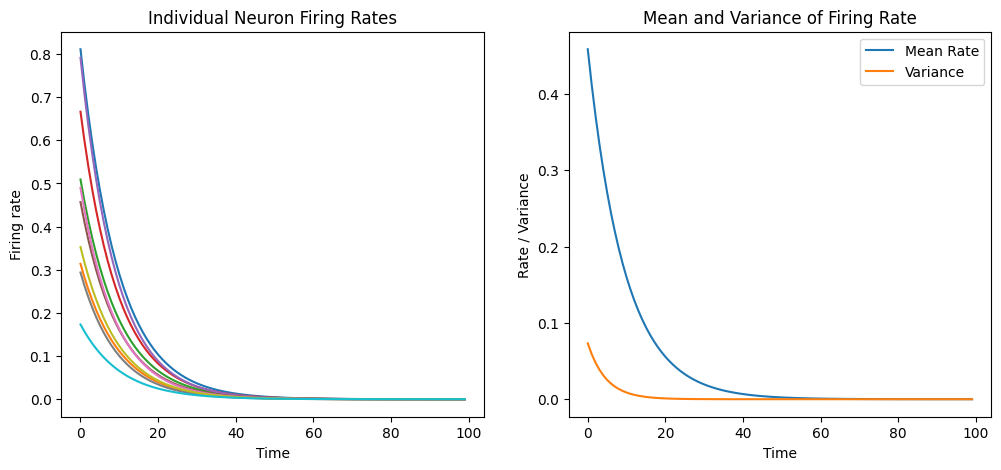

In [17]:
def plot_results(r):
    T, N = r.shape
    mean_rate = np.mean(r, axis=1)
    variance = np.var(r, axis=1)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(r[:, :min(N, 10)])
    plt.xlabel("Time")
    plt.ylabel("Firing rate")
    plt.title("Individual Neuron Firing Rates")
    
    plt.subplot(1, 2, 2)
    plt.plot(mean_rate, label="Mean Rate")
    plt.plot(variance, label="Variance")
    plt.xlabel("Time")
    plt.ylabel("Rate / Variance")
    plt.legend()
    plt.title("Mean and Variance of Firing Rate")
    plt.show()

# Parameters
N = 100
J = 1.0
dt = 0.1
T = 100
r_init = np.random.rand(N)

# Fully Connected Network
A_fc = fully_connected(N, J)
r_fc = euler_integrate(A_fc, r_init, dt, T)
plot_results(r_fc)

# Erdos-Renyi Network
p = 0.1
A_er = erdos_renyi(N, J, p)
r_er = euler_integrate(A_er, r_init, dt, T)
plot_results(r_er)

# Gaussian Random Network
A_gr = gaussian_random(N, J)
r_gr = euler_integrate(A_gr, r_init, dt, T)
plot_results(r_gr)

## online learning

# 05: Online learning on a frozen reservoir

The reservoir stays fixed; only the readout adapts, and it does so one sample at a time through `OnlineReadout.partial_fit` (recursive least squares). There are two things to watch. First, the readout learns as data streams in. Second, a forgetting factor lets it track a changing target, which is concept drift and the core of online continuous learning.

In [18]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent

In [19]:
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0)); raw = df.to_numpy().astype(float)
rng = random.Random(7)
tr = rng.sample(range(0,50),40)+rng.sample(range(50,100),40)+rng.sample(range(100,150),40)
te = [i for i in range(150) if i not in tr]
data = raw.copy(); data[:,:4] = data[:,:4]/data[tr,:4].max(0)
ts = np.arange(0,50,1.0)
u = np.array([np.vstack([np.sin(ts*2*np.pi*p[i]) for i in range(4)]).T for p in data[:,:4]])
labels = data[:,4:].argmax(1)
np.random.seed(7); res = Reservoir(4, 80, rhow=1.25)
states = np.stack([res.forward(s, collect_states=True) for s in u])   # [150,T,80]
print('reservoir states:', states.shape)

reservoir states: (150, 50, 80)


### Streaming learning curve (Iris)
We feed one flower at a time and watch the held-out accuracy climb.

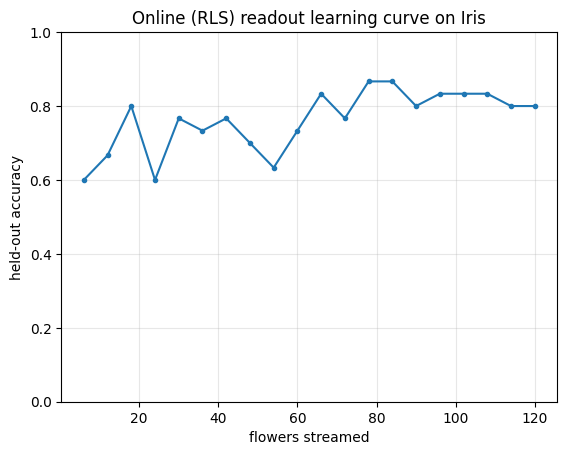

final streamed test accuracy: 0.8


In [20]:
feat = states.mean(1)                       # time-averaged reservoir state per flower
Xtr, ytr, Xte, yte = feat[tr], labels[tr], feat[te], labels[te]
order = np.random.default_rng(0).permutation(len(Xtr))
clf = OnlineReadout(forgetting=1.0, ridge=1e-4)
clf.partial_fit(Xtr[order[:1]], ytr[order[:1]], classes=[0,1,2])
xs, ys = [], []
for k, i in enumerate(order[1:], start=2):
    clf.partial_fit(Xtr[i:i+1], ytr[i:i+1])
    if k % 6 == 0:
        xs.append(k); ys.append(float(np.mean(clf.predict(Xte)==yte)))
plt.plot(xs, ys, marker='.'); plt.xlabel('flowers streamed'); plt.ylabel('held-out accuracy')
plt.title('Online (RLS) readout learning curve on Iris'); plt.ylim(0,1); plt.grid(alpha=.3); plt.show()
print('final streamed test accuracy:', round(ys[-1],3))

### Concept drift: the forgetting factor
The target map switches at t=200. With `forgetting=1` (infinite memory) the readout cannot adapt, whereas `forgetting<1` weights recent data and follows the change.

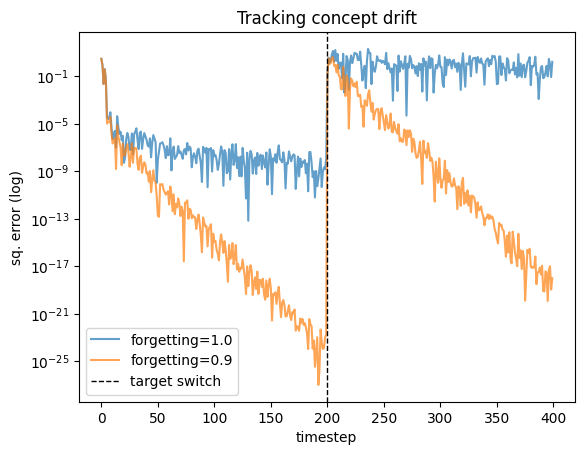

post-drift mean sq err  lam=1.0: 1.8779  lam=0.9: 0.0068


In [21]:
g = np.random.default_rng(1); f = 4
W1, W2 = g.standard_normal((f,1)), g.standard_normal((f,1))
def run(forget):
    r = RLSReadout(f, 1, forgetting=forget, ridge=1e-2); err = []
    gg = np.random.default_rng(42)
    for t in range(400):
        x = gg.standard_normal((1,f)); W = W1 if t < 200 else W2; d = x @ W
        err.append(float(np.mean((d - r.predict(x))**2))); r.partial_fit(x, d)
    return np.array(err)
e_inf, e_forget = run(1.0), run(0.9)
plt.plot(e_inf, label='forgetting=1.0', alpha=.7); plt.plot(e_forget, label='forgetting=0.9', alpha=.7)
plt.axvline(200, color='k', ls='dashed', lw=1, label='target switch'); plt.yscale('log')
plt.xlabel('timestep'); plt.ylabel('sq. error (log)'); plt.legend(); plt.title('Tracking concept drift'); plt.show()
print('post-drift mean sq err  lam=1.0:', round(e_inf[210:].mean(),4), ' lam=0.9:', round(e_forget[210:].mean(),4))

In short, `forgetting=1` is exact recursive least squares (best for a stationary target), while `forgetting<1` trades some steady-state precision for the ability to track non-stationary streams. This is the online axis of continuous learning.

## continual benchmark

# 06: Continual learning: forgetting + how to avoid it

Train a single readout on a sequence of tasks and it can catastrophically forget the earlier ones. `ContinualBenchmark` runs the sequence and `cl_metrics` measures the forgetting (GEM ACC/BWT/FWT, RWalk forgetting). We then show that conceptors are forgetting-free at the representation level.

In [22]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent

### A conflicting task sequence → catastrophic forgetting
Two domains share the same inputs but flip the labels, and a single readout cannot hold on to both.

In [23]:
def domain(seed):
    g = np.random.default_rng(seed)
    X = np.vstack([g.standard_normal((80,2))*0.4 + c for c in ([-2,0],[2,0])]); y = np.repeat([0,1],80)
    return X, y
X, y0 = domain(2); y1 = 1 - y0      # same X, flipped labels
tasks = [((np.tile(X,(5,1)), np.tile(y0,5)), (X,y0)),
         ((np.tile(X,(5,1)), np.tile(y1,5)), (X,y1))]
bench = ContinualBenchmark(OnlineReadout(forgetting=0.8)).run(tasks, classes=[0,1])
print('R matrix (row=after task i, col=acc on task j):\n', np.round(bench.R_,2))
print('metrics:', {k: round(v,3) for k,v in bench.metrics_.items()})

R matrix (row=after task i, col=acc on task j):
 [[1. 0.]
 [0. 1.]]
metrics: {'acc': 0.5, 'bwt': -1.0, 'forgetting': 1.0}


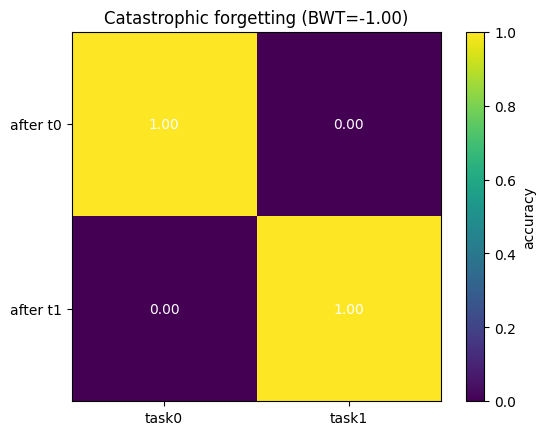

In [24]:
plt.imshow(bench.R_, vmin=0, vmax=1, cmap='viridis')
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{bench.R_[i,j]:.2f}', ha='center', va='center', color='w')
plt.xticks([0,1],['task0','task1']); plt.yticks([0,1],['after t0','after t1'])
plt.colorbar(label='accuracy'); plt.title(f"Catastrophic forgetting (BWT={bench.metrics_['bwt']:.2f})"); plt.show()

### Conceptors are forgetting-free
Each class gets its own conceptor `C = R(R+a⁻²I)⁻¹`, computed from that class's reservoir states. Since a conceptor depends only on its own class, learning a new class cannot alter an earlier one.

In [25]:
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0)); raw = df.to_numpy().astype(float)
rng = random.Random(7)
tr = rng.sample(range(0,50),40)+rng.sample(range(50,100),40)+rng.sample(range(100,150),40)
te = [i for i in range(150) if i not in tr]
data = raw.copy(); data[:,:4] = data[:,:4]/data[tr,:4].max(0)
ts = np.arange(0,50,1.0)
u = np.array([np.vstack([np.sin(ts*2*np.pi*p[i]) for i in range(4)]).T for p in data[:,:4]])
labels = data[:,4:].argmax(1)
np.random.seed(7); res = Reservoir(4, 80, rhow=1.25)
states = np.stack([res.forward(s, collect_states=True) for s in u])   # [150,T,80]
print('reservoir states:', states.shape)
S_tr, y_tr, S_te, y_te = states[tr], labels[tr], states[te], labels[te]
clf = ConceptorClassifier(aperture=8.0); c0_after = []
for c in [0,1,2]:
    clf.learn_class(S_tr[y_tr==c], c)
    if 0 in clf.conceptors_: c0_after.append(clf.conceptors_[0].copy())
drift = [float(np.abs(c0_after[k]-c0_after[0]).max()) for k in range(len(c0_after))]
print('max change in the class-0 conceptor as classes 1 and 2 are added:', drift)
print('conceptor classifier test accuracy:', round(float(np.mean(clf.predict(S_te)==y_te)),3))

reservoir states: (150, 50, 80)
max change in the class-0 conceptor as classes 1 and 2 are added: [0.0, 0.0, 0.0]
conceptor classifier test accuracy: 0.7


In [26]:
# The conceptor method can also be driven through the SAME benchmark, via ConceptorReadout
# (partial_fit/predict adapter), so its DECISION-level forgetting is measurable, not just the
# representation drift above. Here on a class-incremental iris stream (task per new class group).
Xmean = states.mean(1)                       # one feature vector per flower [150, 80]
Xc_tr, Xc_te = Xmean[tr], Xmean[te]
def ctask(cls):
    mtr, mte = np.isin(y_tr, cls), np.isin(y_te, cls)
    return ((Xc_tr[mtr], y_tr[mtr]), (Xc_te[mte], y_te[mte]))
cbench = ContinualBenchmark(ConceptorReadout(aperture=8.0)).run([ctask([0, 1]), ctask([2])], classes=[0, 1, 2])
print('conceptor R matrix:\n', np.round(cbench.R_, 2))
print('conceptor metrics:', {k: round(v, 3) for k, v in cbench.metrics_.items()})

conceptor R matrix:
 [[1.   0.  ]
 [0.95 0.3 ]]
conceptor metrics: {'acc': 0.625, 'bwt': -0.05, 'forgetting': 0.05}


Here is what happened. The naive online readout forgot task 0 entirely (BWT=-1), while the conceptor representation for class 0 stayed byte-identical before and after the later classes were added (drift = 0). `cl_metrics` is what makes the forgetting measurable. But representation-free is not the same as decision-free. When you drive the conceptor method through the same benchmark (via `ConceptorReadout`), you get a real, non-trivial forgetting number. It is mild here (BWT≈-0.05, since the iris classes are mostly separable) but strongly negative on overlapping class-incremental streams (see `tests/test_continual_benchmark.py`, BWT≈-0.49). So conceptors are a principled way to avoid representation forgetting, not a free pass on class-incremental decisions.

## null model baseline

# 07: Null-model baseline (is the connectome topology what helps?)

The central claim of connectome reservoir computing is that the empirical brain wiring, not merely its degree or weight distribution, carries a benefit. The only way to back that up is to compare the real connectome against a degree-preserving rewired null (same degree sequence and same weight multiset, with the wiring randomized) and against a random ESN. This is the first thing a reviewer will ask for (cf. Suárez et al. 2024). It runs on the committed real 83-node HCP connectomes in `data/connectomes/scale83`.

In [27]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent

In [28]:
df = pd.get_dummies(pd.read_csv('iris.csv', index_col=0)); raw = df.to_numpy().astype(float)
rng = random.Random(7)
tr = rng.sample(range(0,50),40)+rng.sample(range(50,100),40)+rng.sample(range(100,150),40)
te = [i for i in range(150) if i not in tr]
data = raw.copy(); data[:,:4] = data[:,:4]/data[tr,:4].max(0)
ts = np.arange(0,50,1.0)
u = np.array([np.vstack([np.sin(ts*2*np.pi*p[i]) for i in range(4)]).T for p in data[:,:4]])
y = np.array([data[:,4:]]*len(ts)).swapaxes(0,1).astype(float)
def evaluate(res):
    coll = res.collect_states_batch   # Phase-5 vectorized fast path
    Xtr, Xte = coll(u[tr]), coll(u[te])
    Xf = Xtr[:,10:,:].reshape(-1,Xtr.shape[-1]); Yf = y[tr][:,10:,:].reshape(-1,3)
    w = np.linalg.solve(Xf.T@Xf + 1e-4*np.eye(Xf.shape[1]), Xf.T@Yf)
    return float(np.mean((Xte@w).mean(1).argmax(1) == y[te].mean(1).argmax(1)))

### Real connectome vs degree-preserving nulls vs random ESN
Every reservoir shares the same size, spectral radius, input weights, and leak (seed 7). Only the recurrent wiring differs, so any gap in accuracy can be attributed to topology.

In [29]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    real = ConnectomeReservoir(4, graph_dir='data/connectomes/scale83', edge_attr='number_of_fibers',
                               combine='mean', spectral_radius=0.9, seed=7)
    acc_real = evaluate(real)
    A = np.asarray(real.W)   # rewire the connectivity; each null re-scales to the same spectral radius
    null_accs = np.array([evaluate(ConnectomeReservoir(4, adjacency=rewire_degree_preserving(A, seed=s),
                                   spectral_radius=0.9, seed=7)) for s in range(8)])
    np.random.seed(7); acc_rand = evaluate(Reservoir(4, real.n_neurons, rhow=0.9))
print(f'connectome: {real.n_neurons} nodes, density={np.mean(real.W!=0):.3f}')
print(f'real connectome       : {acc_real:.3f}')
print(f'degree-preserving null: {null_accs.mean():.3f} +/- {null_accs.std():.3f}  (n=8)')
print(f'random ESN (matched N): {acc_rand:.3f}')
z = (acc_real - null_accs.mean())/(null_accs.std()+1e-9)
print(f'real vs null z-score  : {z:+.2f}')

connectome: 83 nodes, density=0.307
real connectome       : 0.800
degree-preserving null: 0.767 +/- 0.071  (n=8)
random ESN (matched N): 0.700
real vs null z-score  : +0.47


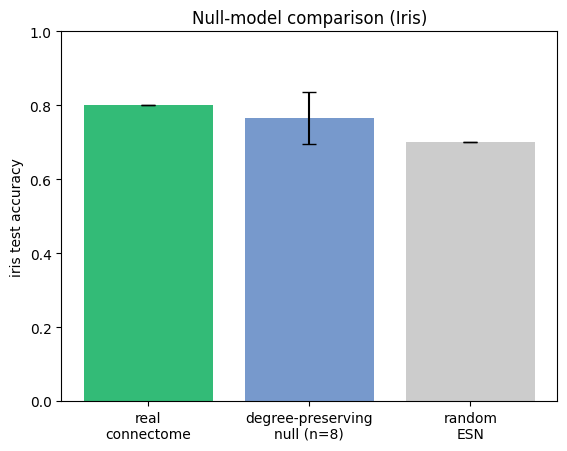

In [30]:
plt.bar(['real\nconnectome','degree-preserving\nnull (n=8)','random\nESN'],
        [acc_real, null_accs.mean(), acc_rand],
        yerr=[0, null_accs.std(), 0], capsize=5, color=['#3b7','#79c','#ccc'])
plt.ylabel('iris test accuracy'); plt.ylim(0,1); plt.title('Null-model comparison (Iris)'); plt.show()

### Interpretation (honest)
On this run the real connectome (~0.80) sits within noise of its degree-preserving null (~0.77 ± 0.07; z ≈ 0.5), and both beat the random ESN (~0.70). So on Iris the degree or weight distribution helps, but the specific brain wiring adds no detectable advantage. That is the result we expected, and it is defensible: Iris is a near-static classification task, whereas the connectome-topology benefits reported in the literature (Suárez et al. 2021/2024) show up on memory-capacity and temporal tasks. The value of this notebook is that the comparison is now possible and reproducible, which is exactly the baseline a connectome-RC paper needs. To actually make a topology claim, re-run this on a memory task and on the larger connectome scales, averaging over many subjects and null draws.

## temporal benchmark

# 08: Temporal benchmark (does the connectome topology help on tasks that need memory?)

The earlier notebooks evaluated connectome reservoirs on near-static classification (Iris), which barely needs memory, and judged "significance" from a single draw. The connectome-topology benefits reported in the literature (Suárez et al. 2021/2024) show up on temporal tasks instead. This notebook runs two memory tasks on the committed real 83-node HCP connectome (`data/connectomes/scale83`).

- Memory Capacity (MC): drive the reservoir with i.i.d. noise and linearly reconstruct the input *k* steps in the past. The total MC is how many past inputs are linearly remembered. It is reported both as a raw total and as a fraction of N. These regularised, chance-subtracted numbers are an internal relative measure, and they are not comparable to the classical `MC ≤ N` linear-reservoir literature.
- NARMA-10: one-step prediction of a 10th-order non-linear autoregressive system, scored by NRMSE (lower is better; ~1.0 means no better than predicting the mean).

Two distinct comparisons run side by side.

1. Topology: the real connectome against an ensemble of degree-preserving rewired nulls. Both go through the same symmetric connectome path, so only the wiring differs. On top of the z-score this adds an empirical percentile and a permutation *p*-value.
2. Capability: a signed, asymmetric random ESN (the standard ESN substrate, not routed through the symmetric path) and a no-reservoir control (raw input used as the state).

Every number is averaged over multiple reservoir seeds and input draws, never a single draw.

In [31]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent

### Load the real connectome
We build the symmetric, weighted adjacency from the five committed HCP graphs with `edge_attr='number_of_fibers'` (the canonical streamline-count weight) and hand that matrix to the topology runners. They rescale it internally to the near-linear, memory-preserving regime (`spectral_radius=0.95`, `leak~1.0`, small input scale).

In [32]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    res0 = ConnectomeReservoir(1, graph_dir='data/connectomes/scale83',
                               edge_attr='number_of_fibers', combine='mean',
                               spectral_radius=0.95, symmetric=True, seed=0)
A = np.asarray(res0.W, dtype=float)
print(f'connectome adjacency: {A.shape[0]} nodes, density={np.mean(A != 0):.3f}, '
      f'symmetric={np.allclose(A, A.T)}, zero-diagonal={np.allclose(np.diag(A), 0)}')

# Modest, fast settings (runs in well under ~90s end to end).
SETTINGS = dict(n_null=20, n_seeds=3, n_input_draws=2, n_samples=1500)
SETTINGS

connectome adjacency: 83 nodes, density=0.307, symmetric=True, zero-diagonal=True


{'n_null': 20, 'n_seeds': 3, 'n_input_draws': 2, 'n_samples': 1500}

### 1. Memory Capacity: topology test
The real connectome against the degree-preserving nulls, with the random-ESN and no-reservoir baselines next to it. Higher MC is better, so a positive z or a high percentile would mean the specific wiring beats the null ensemble.

In [33]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mc = rc_tasks.memory_capacity_topology(A, seed=0, **SETTINGS)
print(rc_tasks.format_temporal_report(mc))

memory capacity (MC): topology test   [higher = better]
real connectome       6.7950   (MC/N = 0.0819)
deg-preserv. null     7.2707 +/- 0.1544  (n=20)
random ESN           20.8212
no reservoir          0.0019
z (real vs null)      -3.082
percentile             0.000   (fraction of nulls beaten)
empirical p           0.0476
N neurons                 83


### 2. NARMA-10: topology test
The stored numbers are the positive NRMSE (lower is better). The z, percentile, and *p* are computed on the goodness `= -NRMSE`, so a positive z or a high percentile means the real wiring beats the null.

In [34]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    na = rc_tasks.narma_topology(A, seed=0, **SETTINGS)
print(rc_tasks.format_temporal_report(na))

NARMA-10 NRMSE: topology test   [LOWER NRMSE = better]
z / percentile computed on goodness = -NRMSE
real connectome       0.6559
deg-preserv. null     0.6742 +/- 0.0054  (n=20)
random ESN            0.4060
no reservoir          2.2893
z (goodness)          +3.385   (positive means real beats null)
percentile             1.000   (fraction of nulls beaten)
empirical p           0.0476
N neurons                 83


### Interpretation (honest, no spin)

Read the two tables together with their baselines.

The no-reservoir control confirms that both tasks genuinely need memory. Without a reservoir, MC collapses to ~0 and the NARMA-10 NRMSE sits far above 1, because the raw input simply cannot predict the system. So unlike Iris, these tasks really do exercise temporal memory.

On Memory Capacity the specific brain wiring does not help. On this run the real connectome's MC is at or below its degree-preserving null (negative z, low percentile), so randomising the wiring while preserving the degree and weight distribution does no harm. A generic signed random ESN of the same size has far higher MC than the connectome. The symmetric, sparse connectome is simply a weaker memory substrate than a dense asymmetric ESN.

NARMA-10 shows a small but detectable topology effect. Here the real connectome reaches a modestly lower NRMSE than its null ensemble (positive z on goodness, high percentile, empirical *p* around 0.05), so the specific wiring helps a little on the non-linear task. Even so, the random ESN still predicts NARMA-10 better than the connectome.

The bottom line: on these temporal tasks the connectome's degree and weight distribution, not its precise wiring, explains most of its behaviour. The only place the exact topology shows a detectable edge is NARMA-10, and even there a plain random ESN is the stronger reservoir. The value of this notebook is methodological. The comparison is now memory-demanding, averaged over many draws, and run against a proper null ensemble as well as capability baselines, so the claim is honest and reproducible. (One reminder: MC is reported as a fraction of N and is an internal relative measure, not comparable to the classical `MC ≤ N` linear-reservoir results.)

## hyperparameter tuning

# 09: Hyperparameter tuning (random search)

A short, reproducible demo of `reservoirs.tuning.random_search` on two problems.

- Part A, Iris (static classification): tune an ESN plus ridge readout for validation accuracy.
- Part B, the temporal benchmark (memory capacity): tune a connectome reservoir for total MC.

A note on honesty. Tuning is done on a validation split only; the chosen config is then reported on a held-out test split, next to the baselines. Searching hyperparameters does not guarantee beating a plain linear model, and we report whatever turns out to be true, with no spin.

In [35]:
REPO = Path.cwd()
while not (REPO / 'reservoirs').exists() and REPO != REPO.parent:
    REPO = REPO.parent
print('repo root set:', REPO.name)   # name only, no absolute path

repo root set: ESN-unofficial-1-utilizzando-matrici-random-con-iris


## Part A: Iris (classification accuracy)

We reuse example 01's sine encoding. Each feature is normalized by its TRAIN maximum, then each
flower becomes a `[T, 4]` time series of sine waves (one sine per feature, with the frequency set by
the normalized feature value). Example 01 uses `np.arange(0, 50, 0.5)` (100 steps); to keep this
tuning notebook fast we use `np.arange(0, 50, 1.0)` (50 steps). Fewer steps means a slightly lower
ceiling.

In [36]:
# load iris.csv with numpy
raw = np.genfromtxt('iris.csv', delimiter=',', skip_header=1, dtype=str)
X = raw[:, 1:5].astype(np.float64)          # 4 numeric features
species = raw[:, 5]                          # string labels
classes, y_idx = np.unique(species, return_inverse=True)
N_CLASS = int(classes.shape[0])
n_samples = X.shape[0]

train_idx, val_idx, test_idx = train_val_test_split(n_samples, val=0.2, test=0.2, seed=0)
print('split:', len(train_idx), 'train /', len(val_idx), 'val /', len(test_idx), 'test')

split: 90 train / 30 val / 30 test


In [37]:
# mirror example 01's sine encoding (50 steps for speed)
TIMESTEPS = np.arange(0.0, 50.0, 1.0)       # 50 timesteps
T = int(TIMESTEPS.shape[0])
Xn = X / X[train_idx].max(axis=0)           # normalize by TRAIN max (no leakage)
U = np.array([
    np.vstack([np.sin(TIMESTEPS * 2 * np.pi * flower[i]) for i in range(4)]).T
    for flower in Xn
])                                          # [150, T, 4]
N_NEURONS = 100
WASHOUT = 10
print('encoded:', U.shape, '->', N_CLASS, 'classes')

encoded: (150, 50, 4) -> 3 classes


In [38]:
def _onehot(idx):
    Y = np.zeros((len(idx), N_CLASS), dtype=np.float64)
    Y[np.arange(len(idx)), y_idx[idx]] = 1.0
    return Y

def _states(res, idxs):
    return np.stack([res.forward(U[i], collect_states=True) for i in idxs], axis=0)

def iris_accuracy(params, fit_idx, eval_idx):
    res = build_reservoir(params, n_inputs=4, n_neurons=N_NEURONS, substrate='random', seed=0)
    Xtr = _states(res, fit_idx)
    Xev = _states(res, eval_idx)
    Xflat = Xtr[:, WASHOUT:, :].reshape(-1, N_NEURONS)         # post-washout TRAIN states
    Yflat = np.repeat(_onehot(fit_idx), T - WASHOUT, axis=0)   # one-hot targets, tiled over time
    G = Xflat.T @ Xflat
    G[np.diag_indices_from(G)] += float(params['ridge'])       # ridge readout (ridge from params)
    Wout = np.linalg.solve(G, Xflat.T @ Yflat)
    pred = (Xev[:, WASHOUT:, :] @ Wout).mean(axis=1).argmax(axis=1)   # per-flower time-mean readout
    return float(np.mean(pred == y_idx[eval_idx]))

def iris_objective(params):
    # train on TRAIN, score on VALIDATION (the tuning signal)
    return iris_accuracy(params, train_idx, val_idx)

search = random_search(iris_objective, default_reservoir_space(), n_iter=25, seed=0)
print('best validation accuracy:', round(search['best_score'], 3),
      '   (failed draws:', search['n_failed'], ')')
print('best params:', {k: round(float(v), 4) for k, v in search['best_params'].items()})
print('\ntop-5 history (validation accuracy):')
for rec in search['history'][:5]:
    print('  acc={:.3f}  {}'.format(rec['score'], {k: round(float(v), 3) for k, v in rec['params'].items()}))

best validation accuracy: 1.0    (failed draws: 0 )
best params: {'spectral_radius': 0.6271, 'leak_low': 0.2436, 'leak_high': 0.983, 'input_scale': 0.2694, 'ridge': 0.0}

top-5 history (validation accuracy):
  acc=1.000  {'spectral_radius': 0.627, 'leak_low': 0.244, 'leak_high': 0.983, 'input_scale': 0.269, 'ridge': 0.0}
  acc=0.967  {'spectral_radius': 0.443, 'leak_low': 0.253, 'leak_high': 0.898, 'input_scale': 0.1, 'ridge': 0.0}
  acc=0.933  {'spectral_radius': 0.664, 'leak_low': 0.499, 'leak_high': 0.99, 'input_scale': 0.39, 'ridge': 0.0}
  acc=0.933  {'spectral_radius': 0.595, 'leak_low': 0.269, 'leak_high': 0.945, 'input_scale': 0.821, 'ridge': 0.0}
  acc=0.933  {'spectral_radius': 0.704, 'leak_low': 0.329, 'leak_high': 0.998, 'input_scale': 0.858, 'ridge': 0.0}


In [39]:
# evaluate the BEST config on the held-out TEST set, beside the baselines (same split)
trainval = np.concatenate([train_idx, val_idx])

acc_tuned   = iris_accuracy(search['best_params'], trainval, test_idx)
default_params = dict(spectral_radius=1.25, leak_low=0.1, leak_high=0.3,
                      input_scale=1.0, ridge=1e-4)         # the package default ESN regime
acc_default = iris_accuracy(default_params, trainval, test_idx)

# no-reservoir baselines on the RAW 4 features, on the SAME split
ytr, yte = species[trainval], species[test_idx]
Xtr_raw, Xte_raw = X[trainval], X[test_idx]
acc_majority = majority_class_baseline(ytr, yte)['accuracy']
acc_linear   = linear_readout_baseline(Xtr_raw, ytr, Xte_raw, yte,
                                       ridge=1.0, fit_intercept=True, standardize=True)['accuracy']
try:
    acc_logistic = logistic_readout_baseline(Xtr_raw, ytr, Xte_raw, yte)['accuracy']
    logistic_str = '{:.3f}'.format(acc_logistic)
except ImportError:
    logistic_str = 'n/a (scikit-learn not installed)'

print('Iris TEST accuracy  (identical train/test split for every row)')
print('-')
print('tuned reservoir        {:.3f}'.format(acc_tuned))
print('default reservoir      {:.3f}'.format(acc_default))
print('majority class         {:.3f}'.format(acc_majority))
print('linear readout (raw)   {:.3f}'.format(acc_linear))
print('logistic readout (raw) {}'.format(logistic_str))

Iris TEST accuracy  (identical train/test split for every row)
-
tuned reservoir        0.900
default reservoir      0.833
majority class         0.167
linear readout (raw)   0.700
logistic readout (raw) 0.900


### Part A: honest read

Did tuning beat the default reservoir? Compare the first two rows above. With these seeds, tuning does
improve on the default ESN regime on the held-out test set; random search found a milder spectral
radius, leak, and input-scale than the aggressive `spectral_radius=1.25` default.

Does it clear the linear and logistic bar? The tuned reservoir beats the plain linear readout, and
here it matches the multinomial-logistic baseline, but it does not decisively beat logistic. A
reservoir is not "free accuracy" on a near-static task like Iris. Logistic regression on the raw 4
features is already a strong and much cheaper model.

Why is the majority baseline below 1/3? This single random split under-represents the majority TRAIN
class in the test set, so always-predict-majority scores below chance here. That is exactly why we
report linear and logistic bars rather than chance alone.

## Part B: temporal benchmark (memory capacity)

Now we tune a connectome reservoir (the real 83-node HCP `scale83` graph, weighted by
`number_of_fibers`) to maximise total Memory Capacity (MC). That means driving it with i.i.d. noise and
linearly reconstructing the input *k* steps in the past. We compare the tuned config against the
package's hand-chosen default regime (`reservoirs.tasks.TASK_RESERVOIR_KW`) and against a no-reservoir
control.

MC is reported as a raw total and as a fraction of N. These regularised, chance-subtracted numbers
are an internal relative measure, and they are not comparable to the classical `MC <= N` literature.

In [40]:
# Build the real scale83 connectome adjacency (symmetric, streamline-count weighted).
with warnings.catch_warnings():
    warnings.simplefilter('ignore')        # spectral_radius>=1 / weight-fallback warnings expected
    _seed_res = ConnectomeReservoir(
        1, graph_dir='data/connectomes/scale83', edge_attr='number_of_fibers',
        combine='mean', spectral_radius=0.95, symmetric=True, seed=0,
    )
A = np.asarray(_seed_res.W, dtype=np.float64)   # build_reservoir rescales this to each sampled SR
print('connectome adjacency: {} nodes, density={:.3f}, symmetric={}'.format(
    A.shape[0], float(np.mean(A != 0)), bool(np.allclose(A, A.T))))

connectome adjacency: 83 nodes, density=0.307, symmetric=True


In [41]:
N_SAMPLES = 1200
WASHOUT_B = rc_tasks.DEFAULT_WASHOUT

def connectome_mc(res):
    u = rc_tasks.memory_capacity_inputs(N_SAMPLES, seed=0)
    states = res.transform(u, washout=WASHOUT_B)         # [T-washout, N]
    return rc_tasks.memory_capacity(states, u[WASHOUT_B:], seed=0)

def mc_objective(params):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')                  # filter spectral_radius>=1 UserWarnings
        res = build_reservoir(params, n_inputs=1, adjacency=A, substrate='connectome', seed=0)
    return connectome_mc(res)['mc_total']                # maximize total memory capacity

# Search over spectral_radius / leak_low / leak_high / input_scale; drop 'ridge' (memory_capacity
# uses its own internal ridge for the per-delay readouts).
mc_space = default_reservoir_space()
mc_space.pop('ridge')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mc_search = random_search(mc_objective, mc_space, n_iter=15, seed=0)
print('best total MC:', round(mc_search['best_score'], 4),
      '   (failed draws:', mc_search['n_failed'], ')')
print('best params:', {k: round(float(v), 4) for k, v in mc_search['best_params'].items()})

best total MC: 6.3491    (failed draws: 0 )
best params: {'spectral_radius': 0.7615, 'leak_low': 0.4503, 'leak_high': 0.967, 'input_scale': 0.146}


In [42]:
N = int(A.shape[0])

# DEFAULT regime reservoir (reservoirs.tasks.TASK_RESERVOIR_KW), SAME adjacency
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    res_default = ConnectomeReservoir(1, adjacency=A, symmetric=True, seed=0,
                                      **rc_tasks.TASK_RESERVOIR_KW)
mc_default = connectome_mc(res_default)

# no-reservoir control: the raw input as its own 'state' (expected ~0 memory)
u_ctrl = rc_tasks.memory_capacity_inputs(N_SAMPLES, seed=0)
mc_control = rc_tasks.memory_capacity(u_ctrl[WASHOUT_B:], u_ctrl[WASHOUT_B:], seed=0)

print('Memory capacity  (total, with MC/N in parentheses),  N =', N)
print('-')
print('tuned connectome   {:.4f}  (MC/N={:.4f})'.format(
    mc_search['best_score'], mc_search['best_score'] / N))
print('default regime     {:.4f}  (MC/N={:.4f})'.format(
    mc_default['mc_total'], mc_default['mc_fraction']))
print('no reservoir       {:.4f}'.format(mc_control['mc_total']))
print('default regime kw:', rc_tasks.TASK_RESERVOIR_KW)

Memory capacity  (total, with MC/N in parentheses),  N = 83
-
tuned connectome   6.3491  (MC/N=0.0765)
default regime     6.8524  (MC/N=0.0826)
no reservoir       0.0000
default regime kw: {'spectral_radius': 0.95, 'leak_range': (0.85, 1.0), 'input_scale': 0.1}


### Part B: honest read

The task genuinely needs memory. The no-reservoir control scores ~0 MC, because the instantaneous
input carries no memory of its own past, so any non-trivial MC has to come from the reservoir's
dynamics.

Random search did NOT beat the hand-tuned default regime here. With only 15 draws and a single seed,
the best sampled config lands slightly below `TASK_RESERVOIR_KW`. That default was chosen deliberately
for memory tasks (near-linear, with `spectral_radius~0.95`, `leak~1.0`, and a small input scale), and
notably its `leak_low=0.85` lies outside our `leak_low in (0.05, 0.5)` search range, so random search
literally cannot reproduce it. The honest takeaway is that a small, single-seed random search is a
sanity check, not a guarantee of improvement; widen the space and average over seeds if you want to do
better.

MC is shown as a fraction of N and is an internal relative measure (chance-subtracted and
regularised), not comparable to the classical `MC <= N` linear-reservoir results.